# MD Validation 
Note that we have already validation the static nature of MACE vs XTB 

In [42]:
from ase.io import read, write
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import Stationary, ZeroRotation, MaxwellBoltzmannDistribution

import random
import os
import time
import numpy as np
import pylab as pl
from IPython import display

import matplotlib.pyplot as plt

def plots_for_given_temperature (t_fs, temps, energies, duration, T, saveloc = None):
    # Compute means rounded to 3 decimal places
    mean_energy = round(np.mean(energies), 3)
    mean_temp = round(np.mean(temps), 3)
    
    # Create subplots: 1 row, 2 columns
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # --- Energy plot ---
    axs[0].plot(t_fs, energies, color='blue')
    axs[0].axhline(y=mean_energy, color='blue', linestyle='--')
    axs[0].set_xlabel('Time (fs)')
    axs[0].set_ylabel('E (eV/atom)')
    axs[0].legend(['E(t)', f'Avg. Energy: {mean_energy}'], loc = "lower right")
    
    # --- Temperature plot ---
    axs[1].plot(t_fs, temps, color='red')
    axs[1].axhline(y=mean_temp, color='red', linestyle='--')
    axs[1].set_xlabel('Time (fs)')
    axs[1].set_ylabel('T (K)')
    axs[1].legend(['T(t)', f'Avg. Temp: {mean_temp}'], loc = "lower right")
    
    # Adjust layout and show
    fig.suptitle(f'MD for T={T}K finished in {round(duration,2)} mins')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for the suptitle
    # plt.show()

    if saveloc != None:
        plt.savefig(saveloc, dpi=300)

def simpleMD(init_conf, temp, calc, fname, s, T):
    init_conf.set_calculator(calc)

    #initialize the temperature
    random.seed(701) #just making sure the MD failure is reproducible
    MaxwellBoltzmannDistribution(init_conf, temperature_K=300) #initialize temperature at 300
    Stationary(init_conf)
    ZeroRotation(init_conf)

    dyn = Langevin(init_conf, 1.0*units.fs, temperature_K=temp, friction=0.1) #drive system to desired temperature

    %matplotlib inline

    time_fs = []
    temperature = []
    energies = []

    #remove previously stored trajectory with the same name
    os.system('rm -rfv '+fname)

    def write_plot_data():
            dyn.atoms.write(fname, append=True)
            time_fs.append(dyn.get_time()/units.fs)
            temperature.append(dyn.atoms.get_temperature())
            energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))

    print("MD Running!")
    
    dyn.attach(write_plot_data, interval=s)
    t0 = time.time()
    dyn.run(T)
    t1 = time.time()

    duration = (t1-t0)/60
    print("MD finished in {0:.2f} minutes!".format(duration))

    return time_fs, temperature, energies, duration

Initial config loading was causing some problem, rectified by Tolib

In [43]:
 # Let us start with a single molecule
all_configs = read('data/solvent_molecs.xyz', ':')

# determining the nature of information present in each config
# dir(all_configs[0])
# all_configs[0].info
# all_configs[0].info['Nmols']

single_molec_configs = [cfg for cfg in all_configs if cfg.info['Nmols'] == 1]
# len(single_molec_configs)

init_conf = single_molec_configs[100]

In [47]:
#running the MD calculation on the chosen single molecule config

#we can use MACE as a calculator in ASE!
from mace.calculators import MACECalculator
mace_calc = MACECalculator(model_paths=['learned_MACE/mace_learned_N4000_swa_compiled.model'], device='cuda', default_dtype="float32")

# for T in [500, 1500]:
#     t_fs, temps, energies, duration = simpleMD(init_conf, temp=T, calc=mace_calc, fname=f'moldyn/mace_learned_N4000_md_{T}K.xyz', s=10, T=10000)
#     plots_for_given_temperature (t_fs, temps, energies, duration, T, saveloc= os.path.join("moldyn", f"MACE MD {T}K.png"))

runtime = 10 # in ps

t_fs, temps, energies, duration = simpleMD(init_conf, temp=1500, calc=mace_calc, fname=f'moldyn/mace_learned_N4000_md_{500}K_{runtime}ps.xyz', s=10, T=runtime*1000)

Default dtype float32 does not match model dtype float64, converting models to float32.
removed 'moldyn/mace_learned_N4000_md_500K_10ps.xyz'
MD Running!


/tmp/ipykernel_101390/782293538.py:47: DeprecationWarning: Please use atoms.calc = calc
  init_conf.set_calculator(calc)


MD finished in 10.17 minutes!


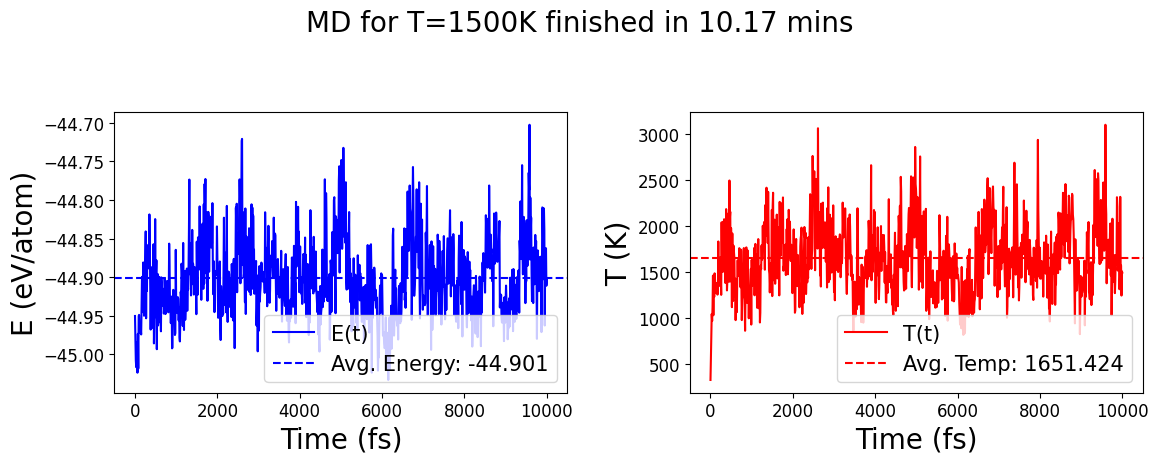

In [48]:
import matplotlib.pyplot as plt

fontsize = 20  # Set your desired base font size here

plt.rcParams.update({
    'font.size': fontsize,
    'axes.titlesize': fontsize + 2,
    'axes.labelsize': fontsize,
    'xtick.labelsize': fontsize * 0.6,
    'ytick.labelsize': fontsize * 0.6,
    'legend.fontsize': fontsize * 0.75,
    'figure.titlesize': fontsize
})

plots_for_given_temperature (t_fs, temps, energies, duration, 1500, saveloc=None)

In [23]:
from ase.io import read
import nglview as nv
import pandas as pd
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

# --- Load a single frame from the XYZ file ---
single_frame = read('moldyn/mace_learned_N4000_md_500K.xyz', index=0)

# --- Display the molecular structure using nglview ---
view = nv.show_ase(single_frame)
view.clear_representations()
view.add_representation('ball+stick')
view.add_representation('label', selection='all', labelType='atomname', labelColor='black', fontSize=1.0)
view.background = 'white'
view.center()
view  # Display the 3D viewer

# Extract atom data
atom_data = {
    'Index': range(len(single_frame)),
    'Name': [atom.symbol for atom in single_frame],  # Atom name or symbol
    'x': single_frame.positions[:, 0],
    'y': single_frame.positions[:, 1],
    'z': single_frame.positions[:, 2]
}

# Create DataFrame
df_atoms = pd.DataFrame(atom_data)

# Display the DataFrame
df_atoms  # In Jupyter, just df_atoms shows the full table

,Index,Name,x,y,z
0,0,C,0.013642,0.573454,0.051898
1,1,O,0.972093,1.091391,0.703277
2,2,O,-0.114726,-0.736204,-0.109223
3,3,O,-0.952100,1.140620,-0.696628
4,4,C,0.763432,-1.638581,0.533632
5,5,C,-1.160780,2.494018,-0.719961
6,6,C,0.475510,-3.082354,0.284853
7,7,H,1.785151,-1.464286,0.154276
8,8,H,0.833445,-1.247710,1.540061
9,9,H,-1.253111,2.853842,0.348506


## DO NOT RUN AGAIN UNLESS THE CONFIG IS CHANGED (xtb calculator)
Takes a lot of time, last MD after 60+ mins

In [ ]:
# Reinitialise the original config
all_configs = read('data/solvent_molecs.xyz', ':')
single_molec_configs = [cfg for cfg in all_configs if cfg.info['Nmols'] == 1]
init_conf = single_molec_configs[100]

from xtb.ase.calculator import XTB
xtb_calc = XTB(method="GFN2-xTB")

# simpleMD(init_conf, temp=1200, calc=xtb_calc, fname='moldyn/xtb_md.xyz', s=10, T=2000)

# for T in [500, 1500]:
#     t_fs, temps, energies, duration = simpleMD(init_conf, T, calc=xtb_calc, fname='moldyn/xtb_md.xyz', s=10, T=10000)
#     plots_for_given_temperature (t_fs, temps, energies, duration, T, saveloc= os.path.join("moldyn", f"XTB MD {T}K.png"))
#     # plt.savefig(os.path.join("moldyn", f"XTB MD {T}K.png"), dpi=300)

t_fs, temps, energies, duration = simpleMD(init_conf, 1500, calc=xtb_calc, fname='moldyn/xtb_gasmd_10ps.xyz', s=10, T=10000)

/tmp/ipykernel_101390/2413219911.py:47: DeprecationWarning: Please use atoms.calc = calc
  init_conf.set_calculator(calc)


MD Running!


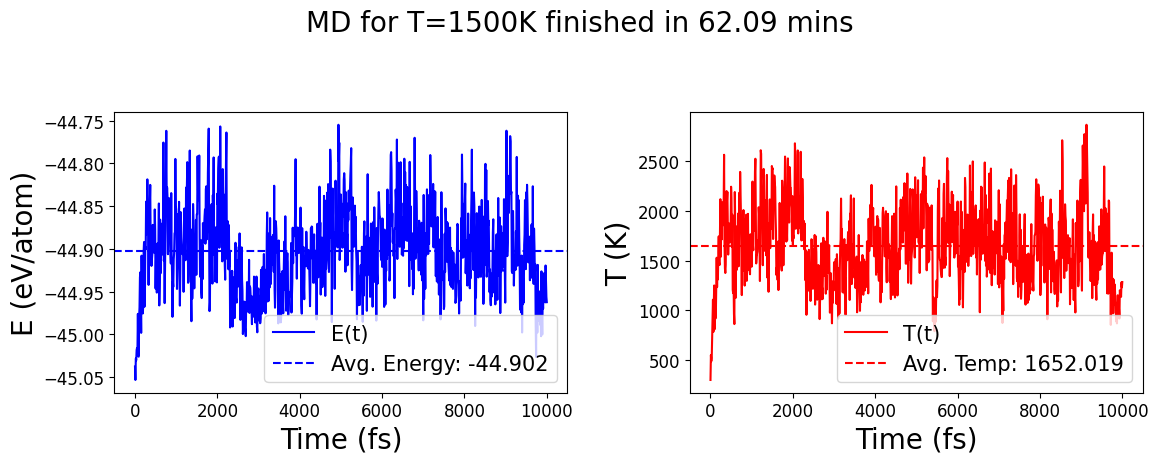

In [41]:
plots_for_given_temperature (t_fs, temps, energies, duration, 1500, saveloc= None) # saveloc = os.path.join("moldyn", f"XTB MD {T}K.png)

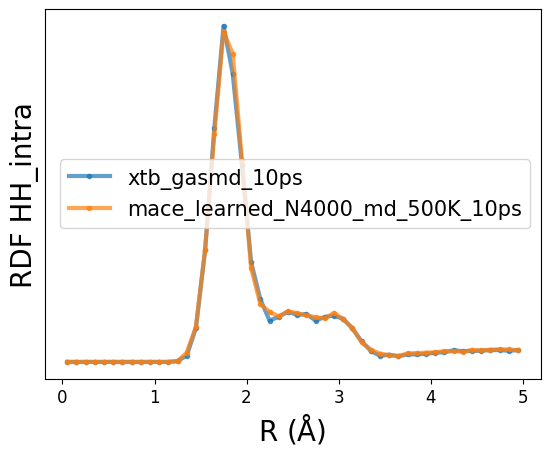

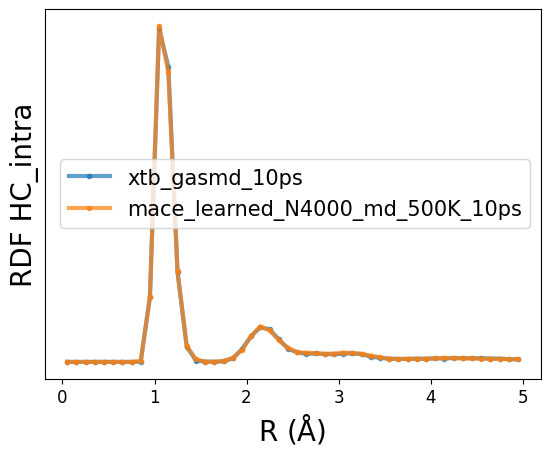

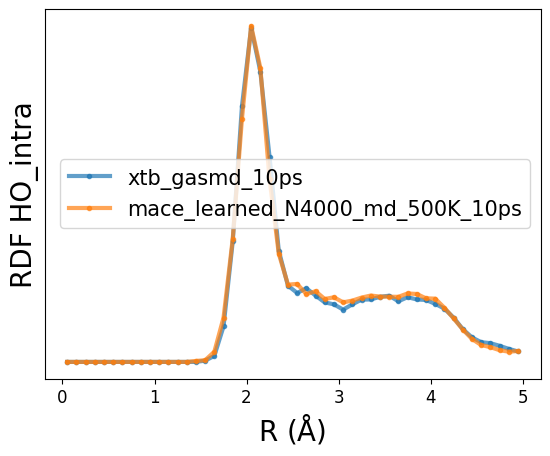

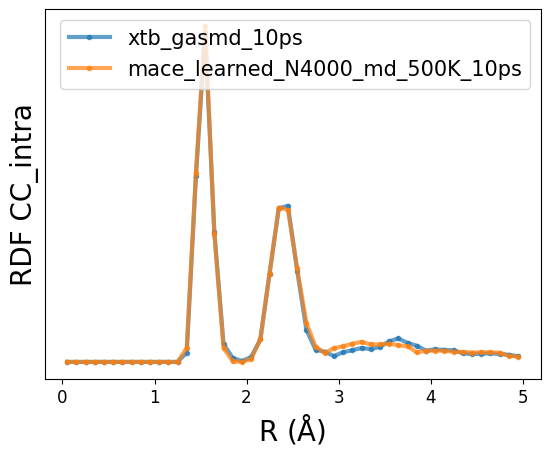

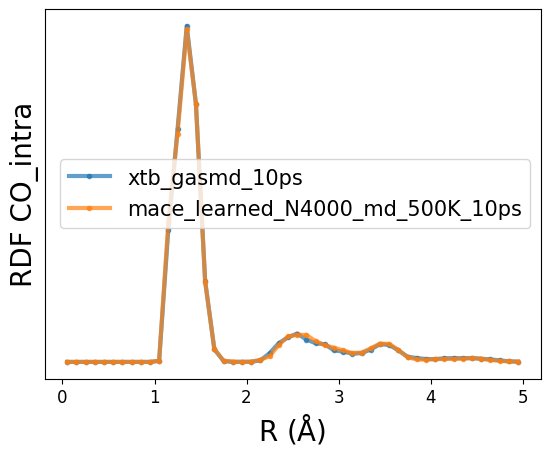

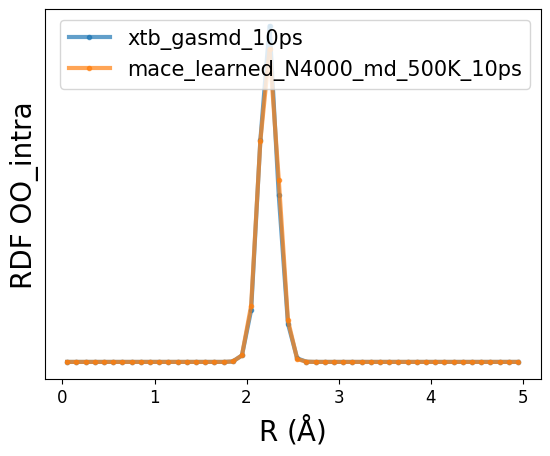

In [49]:
from aseMolec import anaAtoms as aa
from matplotlib import pyplot as plt

# tag = 'HH_intra' #choose one of 'HH_intra', 'HC_intra', 'HO_intra', 'CC_intra', 'CO_intra', 'OO_intra'
for tag in ['HH_intra', 'HC_intra', 'HO_intra', 'CC_intra', 'CO_intra', 'OO_intra']:
    for f in ['xtb_gasmd_10ps', 'mace_learned_N4000_md_500K_10ps']:
        traj = read('moldyn/'+f+'.xyz', '50:') #ignore first 50 frames
        for at in traj:
            at.pbc = True #create a fake box for RDF compatibility
            at.cell = [100,100,100]
        rdf = aa.compute_rdfs_traj_avg(traj, rmax=5, nbins=50) #aseMolec provides functionality to compute RDFs
        plt.plot(rdf[1], rdf[0][tag], '.-', label=f, alpha=0.7, linewidth=3)
    
    plt.legend();
    plt.yticks([]);
    plt.xlabel(r'R ($\rm \AA$)');
    plt.ylabel('RDF '+tag);
    plt.show()


Shows relatively good balance between the MACE learned model and the XTB calculations. Some RDF pairs are reproduced better than others, but all within the margin of errors.